## Tarea 4
Programa Experto en Inteligencia Artificial con Python  
ML3009 - Series de Tiempo  
Estudiante: Natalia Bonilla Villalobos.  
**Métodos ARIMA**

<a id="menu"></a>

# Menú
- [Ejercicio 1](#ej1)
- [Ejercicio 2](#ej2)
- [Ejercicio 3](#ej3)

In [9]:
import math
import warnings
import statistics
import numpy as np
import pandas as pd
from scipy import stats, signal
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from statsmodels.tsa.api import ExponentialSmoothing  # Holt-Winters
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.api import SARIMAX
from statsforecast.models import AutoARIMA
from statsforecast.arima import arima_string

from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)
from abc import ABCMeta, abstractmethod

warnings.filterwarnings("ignore")
from numpy import corrcoef

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense

import plotly.io as pio
pio.renderers.default = "notebook_connected"

## Modelos Predictivos

In [10]:
class BasePrediccion(metaclass = ABCMeta):    
  @abstractmethod
  def forecast(self):
    pass

class Prediccion(BasePrediccion):
  def __init__(self, modelo):
    self.__modelo = modelo
  
  @property
  def modelo(self):
    return self.__modelo  
  
  @modelo.setter
  def modelo(self, modelo):
    if(isinstance(modelo, Modelo)):
      self.__modelo = modelo
    else:
      warnings.warn('El objeto debe ser una instancia de Modelo.')
  
class meanfPrediccion(Prediccion):
  def __init__(self, modelo):
    super().__init__(modelo)
  
  def forecast(self, steps = 1):
    res = []
    for i in range(steps):
      res.append(self.modelo.coef)
    
    start = self.modelo.ts.index[-1]
    freq  = self.modelo.ts.index.freqstr
    fechas = pd.date_range(start = start, periods = steps+1, freq = freq)
    fechas = fechas.delete(0)
    res = pd.Series(res, index = fechas)
    return(res)

class naivePrediccion(Prediccion):
  def __init__(self, modelo):
    super().__init__(modelo)
  
  def forecast(self, steps = 1):
    res = []
    for i in range(steps):
      res.append(self.modelo.coef)
    
    start = self.modelo.ts.index[-1]
    freq  = self.modelo.ts.index.freqstr
    fechas = pd.date_range(start = start, periods = steps+1, freq = freq)
    fechas = fechas.delete(0)
    res = pd.Series(res, index = fechas)
    return(res)

class snaivePrediccion(Prediccion):
  def __init__(self, modelo):
    super().__init__(modelo)
  
  def forecast(self, steps = 1):
    res = []
    pos = 0
    for i in range(steps):
      if pos >= len(self.modelo.coef):
        pos = 0
      res.append(self.modelo.coef[pos])
      pos = pos + 1
    
    start = self.modelo.ts.index[-1]
    freq  = self.modelo.ts.index.freqstr
    fechas = pd.date_range(start = start, periods = steps+1, freq = freq)
    fechas = fechas.delete(0)
    res = pd.Series(res, index = fechas)
    return(res)

class driftPrediccion(Prediccion):
  def __init__(self, modelo):
    super().__init__(modelo)
  
  def forecast(self, steps = 1):
    res = []
    for i in range(steps):
      res.append(self.modelo.ts[-1] + self.modelo.coef * i)
    
    start = self.modelo.ts.index[-1]
    freq  = self.modelo.ts.index.freqstr
    fechas = pd.date_range(start = start, periods = steps+1, freq = freq)
    fechas = fechas.delete(0)
    res = pd.Series(res, index = fechas)
    return(res)

class RNN_TSPrediccion(Prediccion):
  def __init__(self, modelo):
    super().__init__(modelo)
    self.__scaler = MinMaxScaler(feature_range = (0, 1))
    self.__X = self.__scaler.fit_transform(self.modelo.ts.to_frame())
  
  def __split_sequence(self, sequence, n_steps):
    X, y = [], []
    for i in range(n_steps, len(sequence)):
      X.append(self.__X[i-n_steps:i, 0])
      y.append(self.__X[i, 0])
    return np.array(X), np.array(y)
  
  def forecast(self, steps = 1):
    res = []
    p = self.modelo.p
    for i in range(steps):
      y_pred = [self.__X[-p:].tolist()]
      X, y = self.__split_sequence(self.__X, p)
      X = np.reshape(X, (X.shape[0], X.shape[1], 1))
      self.modelo.m.fit(X, y, epochs = 10, batch_size = 1, verbose = 0)
      pred = self.modelo.m.predict(y_pred)
      res.append(self.__scaler.inverse_transform(pred).tolist()[0][0])
      self.__X = np.append(self.__X, pred.tolist(), axis = 0)
    
    start  = self.modelo.ts.index[-1]
    freq   = self.modelo.ts.index.freqstr
    fechas = pd.date_range(start = start, periods = steps+1, freq = freq)
    fechas = fechas.delete(0)
    res = pd.Series(res, index = fechas)
    return(res)

class HW_Prediccion(Prediccion):
  def __init__(self, modelo, alpha, beta, gamma):
    super().__init__(modelo)
    self.__alpha = alpha
    self.__beta  = beta
    self.__gamma = gamma
  
  @property
  def alpha(self):
    return self.__alpha
  
  @property
  def beta(self):
    return self.__beta 
  
  @property
  def gamma(self):
    return self.__gamma
  
  def forecast(self, steps = 1):
    res = self.modelo.forecast(steps)
    return(res)

class ARIMA_Prediccion(Prediccion):
  def __init__(self, modelo, p, d, q):
    super().__init__(modelo)
    self.__p = p
    self.__d = d
    self.__q = q
  
  @property
  def p(self):
    return self.__p
  
  @property
  def d(self):
    return self.__d
  
  @property
  def q(self):
    return self.__q
  
  def forecast(self, steps = 1):
    res = self.modelo.forecast(steps)
    return(res)

class SARIMA_Prediccion(Prediccion):
  def __init__(self, modelo, p, d, q, P, D, Q, S):
    super().__init__(modelo)
    self.__p = p
    self.__d = d
    self.__q = q
    self.__P = P
    self.__D = D
    self.__Q = Q
    self.__S = S
  
  @property
  def p(self):
    return self.__p
  
  @property
  def d(self):
    return self.__d
  
  @property
  def q(self):
    return self.__q
  
  @property
  def P(self):
    return self.__P
  
  @property
  def D(self):
    return self.__D
  
  @property
  def Q(self):
    return self.__Q
  
  @property
  def S(self):
    return self.__S
  
  def forecast(self, steps = 1):
    res = self.modelo.forecast(steps)
    return(res)

class BaseModelo(metaclass = ABCMeta):    
  @abstractmethod
  def fit(self):
    pass

class Modelo(BaseModelo):
  def __init__(self, ts):
    self.__ts = ts
    self._coef = None
  
  @property
  def ts(self):
    return self.__ts  
  
  @ts.setter
  def ts(self, ts):
    if(isinstance(ts, pd.core.series.Series)):
      if(ts.index.freqstr != None):
        self.__ts = ts
      else:
        warnings.warn('ERROR: No se indica la frecuencia de la serie de tiempo.')
    else:
      warnings.warn('ERROR: El parámetro ts no es una instancia de serie de tiempo.')
  
  @property
  def coef(self):
    return self._coef
  
class meanf(Modelo):
  def __init__(self, ts):
    super().__init__(ts)
  
  def fit(self):
    self._coef = statistics.mean(self.ts)
    res = meanfPrediccion(self)
    return(res)

class naive(Modelo):
  def __init__(self, ts):
    super().__init__(ts)
  
  def fit(self):
    self._coef = self.ts[-1]
    res = naivePrediccion(self)
    return(res)

class snaive(Modelo):
  def __init__(self, ts):
    super().__init__(ts)
  
  def fit(self, h = 1):
    self._coef = self.ts.values[-h:]
    res = snaivePrediccion(self)
    return(res)

class drift(Modelo):
  def __init__(self, ts):
    super().__init__(ts)
  
  def fit(self):
    self._coef = (self.ts[-1] - self.ts[0]) / len(self.ts)
    res = driftPrediccion(self)
    return(res)
  
class RNN_TS(Modelo):
  def __init__(self, ts, p = 1, lstm_units = 50, dense_units = 1, optimizer = 'rmsprop', loss = 'mse'):
    super().__init__(ts)
    self.__p = p
    self.__m = Sequential()
    self.__m.add(LSTM(units = lstm_units, input_shape = (p, 1)))
    self.__m.add(Dense(units = dense_units))
    self.__m.compile(optimizer = optimizer, loss = loss)
  
  @property
  def m(self):
    return self.__m
  
  @property
  def p(self):
    return self.__p
  
  def fit(self):
    res = RNN_TSPrediccion(self)
    return(res)

class HW_calibrado(Modelo):
  def __init__(self, ts, test, trend = 'add', seasonal = 'add'):
    super().__init__(ts)
    self.__test = test
    self.__modelo = ExponentialSmoothing(ts, trend = trend, seasonal = seasonal)
  
  @property
  def test(self):
    return self.__test  
  
  @test.setter
  def test(self, test):
    if(isinstance(test, pd.core.series.Series)):
      if(test.index.freqstr != None):
        self.__test = test
      else:
        warnings.warn('ERROR: No se indica la frecuencia de la serie de tiempo.')
    else:
      warnings.warn('ERROR: El parámetro ts no es una instancia de serie de tiempo.')
  
  def fit(self, paso = 0.1):
    error = float("inf")
    alpha = paso
    while alpha <= 1:
      beta = 0
      while beta <= 1:
        gamma = 0
        while gamma <= 1:
          model_fit = self.__modelo.fit(smoothing_level = alpha, smoothing_slope = beta, smoothing_seasonal = gamma)
          pred      = model_fit.forecast(len(self.test))
          mse       = sum((pred - self.test)**2)
          if mse < error:
            res_alpha = alpha
            res_beta  = beta
            res_gamma = gamma
            error = mse
            res = model_fit
          gamma += paso
        beta += paso
      alpha += paso
    return(HW_Prediccion(res, res_alpha, res_beta, res_gamma))

class ARIMA_calibrado(Modelo):
  def __init__(self, ts, test):
    super().__init__(ts)
    self.__test = test
  
  @property
  def test(self):
    return self.__test  
  
  @test.setter
  def test(self, test):
    if(isinstance(test, pd.core.series.Series)):
      if(test.index.freqstr != None):
        self.__test = test
      else:
        warnings.warn('ERROR: No se indica la frecuencia de la serie de tiempo.')
    else:
      warnings.warn('ERROR: El parámetro ts no es una instancia de serie de tiempo.')
  
  def fit(self, ar = [0, 1, 2]):
    res, res_p, res_d, res_q = (None, 0, 0, 0)
    error = float("inf")
    for p in ar:
      for d in ar:
        for q in ar:
          try:
            with warnings.catch_warnings():
              warnings.simplefilter("ignore")
              modelo    = SARIMAX(self.ts, order = [p, d, q])
              model_fit = modelo.fit(disp = False)
            pred      = model_fit.forecast(len(self.test))
            mse       = sum((pred - self.test)**2)
            if mse < error:
              res_p = p
              res_d = d
              res_q = q
              error = mse
              res   = model_fit
          except:
            modelo = None
    return(ARIMA_Prediccion(res, res_p, res_d, res_q))

class SARIMA_calibrado(Modelo):
  def __init__(self, ts, test):
    super().__init__(ts)
    self.__test = test
  
  @property
  def test(self):
    return self.__test  
  
  @test.setter
  def test(self, test):
    if(isinstance(test, pd.core.series.Series)):
      if(test.index.freqstr != None):
        self.__test = test
      else:
        warnings.warn('ERROR: No se indica la frecuencia de la serie de tiempo.')
    else:
      warnings.warn('ERROR: El parámetro ts no es una instancia de serie de tiempo.')
  
  def fit(self, ar = [0, 1, 2], es = [0, 1], S = None):
    if S is None:
      warnings.warn('ERROR: No se indica el periodo a utilizar (S).')
      return(None)
    res, res_p, res_d, res_q, res_P, res_D, res_Q = (None, 0, 0, 0, 0, 0, 0)
    error = float("inf")
    for p in ar:
      for d in ar:
        for q in ar:
          for P in es:
            for D in es:
              for Q in es:
                try:
                  with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    modelo    = SARIMAX(self.ts, order = [p, d, q], seasonal_order = [P, D, Q, S])
                    model_fit = modelo.fit(disp = False)
                  pred      = model_fit.forecast(len(self.test))
                  mse       = sum((pred - self.test)**2)
                  if mse < error:
                    res_p = p
                    res_d = d
                    res_q = q
                    res_P = P
                    res_D = D
                    res_Q = Q
                    error = mse
                    res = model_fit
                except:
                  modelo = None
    return(SARIMA_Prediccion(res, res_p, res_d, res_q, res_P, res_D, res_Q, S))

## Métodos

### Holt-Winters Calibrado

In [11]:
class HW_Prediccion(Prediccion):
    def __init__(self, modelo, alpha, beta, gamma):
        super().__init__(modelo)
        self.__alpha = alpha
        self.__beta = beta
        self.__gamma = gamma

    @property
    def alpha(self):
        return self.__alpha

    @property
    def beta(self):
        return self.__beta

    @property
    def gamma(self):
        return self.__gamma

    def forecast(self, steps=1):
        res = self.modelo.forecast(steps)
        return res


class HW_calibrado(Modelo):
    def __init__(self, ts, test, trend="add", seasonal="add", seasonal_periods=None):
        super().__init__(ts)
        self.__test = test
        self.__modelo = ExponentialSmoothing(
            ts, trend=trend, seasonal=seasonal, seasonal_periods=seasonal_periods
        )

    @property
    def test(self):
        return self.__test

    @test.setter
    def test(self, test):
        if isinstance(test, pd.core.series.Series):
            if test.index.freqstr != None:
                self.__test = test
            else:
                warnings.warn(
                    "ERROR: No se indica la frecuencia de la serie de tiempo."
                )
        else:
            warnings.warn(
                "ERROR: El parámetro ts no es una instancia de serie de tiempo."
            )

    def fit(self, paso=0.1):
        error = float("inf")
        n = np.append(np.arange(0, 1, paso), 1)
        for alpha in n:
            for beta in n:
                for gamma in n:
                    model_fit = self.__modelo.fit(
                        smoothing_level=alpha,
                        smoothing_trend=beta,
                        smoothing_seasonal=gamma,
                    )
                    pred = model_fit.forecast(len(self.test))
                    mse = sum((pred - self.test) ** 2)
                    if mse < error:
                        res_alpha = alpha
                        res_beta = beta
                        res_gamma = gamma
                        error = mse
                        res = model_fit
        return HW_Prediccion(res, res_alpha, res_beta, res_gamma)

### Redes Neuronales

In [12]:
class LSTM_TSPrediccion(Prediccion):
    def __init__(self, modelo):
        super().__init__(modelo)
        self.__scaler = MinMaxScaler(feature_range=(0, 1))
        self.__X = self.__scaler.fit_transform(self.modelo.ts.to_frame())

    def __split_sequence(self, sequence, n_steps):
        X, y = [], []
        for i in range(n_steps, len(sequence)):
            X.append(self.__X[i - n_steps : i, 0])
            y.append(self.__X[i, 0])
        return np.array(X), np.array(y)

    def forecast(self, steps=1):
        res = []
        p = self.modelo.p
        for i in range(steps):
            y_pred = np.array(self.__X[-p:]).reshape(
                1, p, 1
            )  # y_pred = [self.__X[-p:].tolist()]
            X, y = self.__split_sequence(self.__X, p)
            X = np.reshape(X, (X.shape[0], X.shape[1], 1))
            self.modelo.m.fit(X, y, epochs=10, batch_size=1, verbose=0)
            pred = self.modelo.m.predict(y_pred)
            res.append(self.__scaler.inverse_transform(pred).tolist()[0][0])
            self.__X = np.append(self.__X, pred.tolist(), axis=0)

        start = self.modelo.ts.index[-1]
        freq = self.modelo.ts.index.freqstr
        fechas = pd.date_range(start=start, periods=steps + 1, freq=freq)
        fechas = fechas.delete(0)
        res = pd.Series(res, index=fechas)
        return res


class LSTM_TS(Modelo):
    def __init__(
        self, ts, p=1, lstm_units=50, dense_units=1, optimizer="rmsprop", loss="mse"
    ):
        super().__init__(ts)
        self.__p = p
        self.__m = Sequential()
        self.__m.add(LSTM(units=lstm_units, input_shape=(p, 1)))
        self.__m.add(Dense(units=dense_units))
        self.__m.compile(optimizer=optimizer, loss=loss)

    @property
    def m(self):
        return self.__m

    @property
    def p(self):
        return self.__p

    def fit(self):
        res = LSTM_TSPrediccion(self)
        return res

## Cálculo de errores

In [13]:
class ts_error:
    def __init__(self, preds, real, nombres=None):
        self.__preds = preds
        self.__real = real
        self.__nombres = nombres

    @property
    def preds(self):
        return self.__preds

    @preds.setter
    def preds(self, preds):
        if isinstance(preds, pd.core.series.Series) or isinstance(preds, numpy.ndarray):
            self.__preds = [preds]
        elif isinstance(preds, list):
            self.__preds = preds
        else:
            warnings.warn(
                "ERROR: El parámetro preds debe ser una serie de tiempo o una lista de series de tiempo."
            )

    @property
    def real(self):
        return self.__real

    @real.setter
    def real(self, real):
        self.__real = real

    @property
    def nombres(self):
        return self.__nombres

    @nombres.setter
    def nombres(self, nombres):
        if isinstance(nombres, str):
            nombres = [nombres]
        if len(nombres) == len(self.__preds):
            self.__nombres = nombres
        else:
            warnings.warn("ERROR: Los nombres no calzan con la cantidad de métodos.")

    def RSS(self):
        res = []
        for pred in self.preds:
            res.append(sum((pred - self.real) ** 2))
        return res

    def MSE(self):
        return [pred / len(self.real) for pred in self.RSS()]

    def RMSE(self):
        return [math.sqrt(pred) for pred in self.MSE()]

    def RE(self):
        res = []
        for pred in self.preds:
            res.append(sum(abs(self.real - pred)) / sum(abs(self.real)))
        return res

    def CORR(self):
        res = []
        for pred in self.preds:
            corr = corrcoef(self.real, pred)[0, 1]
            res.append(0 if math.isnan(corr) else corr)
        return res

    def df_errores(self):
        res = pd.DataFrame(
            {
                "MSE": self.MSE(),
                "RMSE": self.RMSE(),
                "RE": self.RE(),
                "CORR": self.CORR(),
            }
        )
        if self.nombres is not None:
            res.index = self.nombres
        return res

    def __escalar(self):
        res = self.df_errores()
        for nombre in res.columns.values:
            res[nombre] = res[nombre] - min(res[nombre])
            res[nombre] = res[nombre] / max(res[nombre]) * 100
        return res

    def plot_errores(self):
        plt.figure(figsize=(8, 8))
        df = self.__escalar()
        if len(df) == 1:
            df.loc[0] = 100

        N = len(df.columns.values)
        angles = [n / float(N) * 2 * math.pi for n in range(N)]
        angles += angles[:1]

        ax = plt.subplot(111, polar=True)

        ax.set_theta_offset(math.pi / 2)
        ax.set_theta_direction(-1)

        plt.xticks(angles[:-1], df.columns.values)

        ax.set_rlabel_position(0)
        plt.yticks(
            [0, 25, 50, 75, 100],
            ["0%", "25%", "50%", "75%", "100%"],
            color="grey",
            size=10,
        )
        plt.ylim(-10, 110)

        for i in df.index.values:
            p = df.loc[i].values.tolist()
            p = p + p[:1]
            ax.plot(angles, p, linewidth=1, linestyle="solid", label=i)
            ax.fill(angles, p, alpha=0.1)

        plt.legend(loc="best")
        plt.show()

    def plotly_errores(self):
        df = self.__escalar()
        etqs = df.columns.values.tolist()
        etqs = etqs + etqs[:1]
        if len(df) == 1:
            df.loc[0] = 100

        fig = go.Figure()

        for i in df.index.values:
            p = df.loc[i].values.tolist()
            p = p + p[:1]
            fig.add_trace(go.Scatterpolar(r=p, theta=etqs, fill="toself", name=i))

        fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[-10, 110])))

        return fig

## Periodograma

In [14]:
class Periodograma:
  def __init__(self, ts):
    self.__ts = ts
    self.__freq, self.__spec = signal.periodogram(ts)
  
  @property
  def ts(self):
    return self.__ts
  
  @property
  def freq(self):
    return self.__freq
  
  @property
  def spec(self):
    return self.__spec
  
  def mejor_freq(self, best = 3):
    res = np.argsort(-self.spec)
    res = res[res != 1][0:best]
    return(self.freq[res])
  
  def mejor_periodos(self, best = 3):
    return(1 / self.mejor_freq(best))
  
  def plot_periodograma(self, best = 3):
    res = self.mejor_freq(best)
    plt.plot(self.freq, self.spec, color = "darkgray")
    for i in range(best):
      plt.axvline(x = res[i], label = "Mejor " + str(i + 1), ls = '--', c = np.random.rand(3))
    plt.legend(loc = "best")
    plt.show()
  
  def plotly_periodograma(self, best = 3):
    res = self.mejor_freq(best)
    fig = go.Figure()
    no_plot = fig.add_trace(
      go.Scatter(x = self.freq, y = self.spec, 
                 mode = 'lines+markers', line_color = 'darkgray')
    )
    for i in range(best):
      v = np.random.rand(3)
      color = "rgb(" + str(v[0]) + ", " + str(v[1]) + ", " + str(v[2]) + ")"
      fig.add_vline(x = res[i], line_width = 2, line_dash = "dash", 
                    annotation_text = "Mejor " + str(i + 1), 
                    line_color = color)
    
    return(fig)

## Funciones Tarea2

In [15]:
# función para verificar si hay fechas faltantes en la columna de fecha, con una frecuencia dada
def hay_fechas_faltantes(datos, col_name_date, frequency):
    df = datos.copy()
    start_date = df[col_name_date].min()
    last_date = df[col_name_date].max()
    date_range = pd.date_range(
        start=start_date, end=last_date, freq=frequency
    ).to_list()

    faltantes = pd.Index(date_range).difference(df[col_name_date])
    if len(faltantes) == 0:
        print(f"Fechas faltantes: {len(df) - len(date_range)}")
    else:
        print(f"Fechas faltantes: {len(df) - len(date_range)}")

    return {"date_range": date_range, "faltantes": faltantes}


# función para rellenar las fechas faltantes, derivadas de la función anterior
#
def rellenar_fechas(datos, col_name_date, serie_fechas_completas):
    df = datos.copy()
    # asegurar datetime
    # df[col_name_date] = pd.to_datetime(df[col_name_date])
    df[col_name_date] = df[col_name_date].astype("datetime64[ns]")

    fechas_faltantes = [
        x for x in serie_fechas_completas if x not in df[col_name_date].to_list()
    ]
    print("Primeras 5 filas:\n", fechas_faltantes[:5])

    completando_serie = pd.concat(
        [df, pd.DataFrame({"Fecha": fechas_faltantes})], ignore_index=True
    )  # Se añaden las fechas faltantes al final
    completando_serie.sort_values(
        by=col_name_date, inplace=True
    )  # Se ordenan las fechas de forma ascendente

    print("\nValores faltantes: ", completando_serie[col_name_date].isnull().sum())

    return completando_serie


def to_serie_tiempo(datos, col_name_date, col_name_values, frequency):
    df = datos.copy()
    df.set_index(col_name_date, inplace=True)
    serie_tiempo = df[col_name_values].asfreq(frequency)
    return serie_tiempo


# def suavizado_movil(datos, size):
#     df = datos.copy()
#     suavizado = df.rolling(
#         size, min_periods=1, center=True
#     ).mean()  # min_periods=1 para que no deje NaN al inicio y al final, center=True para que el promedio se centre en la ventana
#     return suavizado


def train_test(serie_tiempo, test_size):
    test = serie_tiempo[-test_size:]  # ultimos para test
    train = serie_tiempo[:-test_size]  # el resto menos el test para train
    print("Train:", len(train), "\nTest :", len(test))

    return {"train": train, "test": test}

# # Imputa valores faltantes utilizando un suavizado móvil, basado en vecinos cercanos (rolling mean).
# # si to_serie es True, se devuelve la serie de tiempo, si no, se devuelve el dataframe con los valores imputados.
def imputar_valores_faltantes_suavizados(datos_rellenados, col_name_values, size, to_serie=False, frequency=None, col_name_date=None):
    df = datos_rellenados.copy()

    suavizado = (
        df[col_name_values].rolling(window=size, center=True, min_periods=1).mean()
    )

    # Primera imputacion
    df[col_name_values] = (df[col_name_values].fillna(suavizado))

    # Verificar si aun quedan NaN
    faltantes = df[col_name_values].isna().sum()

    if faltantes > 0:
        print(f'Aún quedan {faltantes} valores faltantes. Aplicando interpolación...')
        df[col_name_values] = (df[col_name_values].interpolate(method='linear'))
    else:
        print(f'Todos los valores faltantes fueron imputados con suavizado de {size} datos.')

    # convertir a serie temporal
    if to_serie:
        df = to_serie_tiempo(df, col_name_date, col_name_values, frequency)

    return df

<a id="ej1"></a>
# Ejercicio 1 
[30 puntos] La tabla `consumo_agua.csv` contiene el consumo de agua diario de una región desde el *02 de marzo del 2019* hasta el *30 de noviembre de 2021*. Con la tabla realice lo siguiente:  
- a) Convierta los datos a serie de tiempo y grafique la serie.
- b) Usando la serie original, encuentre el periodo más importante, luego grafique el periodograma.
- c) Usando la serie original, gráfique la auto-correlación Simple `ACF` y la Parcial `PACF`. Con base en estos gráficos y el periodograma explique cuales serían los parámetros más adecuados para el método de `ARIMA`.
- d) Utilizando 15 días para pruebas y el resto de fechas para entrenamiento, genere el modelo usando los parámetros del item anterior.
- e) Genere también los métodos `Holt-Winters`, `Holt-Winters Calibrado`, `Deep Learning`, `AUTO ARIMA` y `SARIMA Calibrado` y compare los resultados.

[↑ Volver al Menú](#menu)


### Preparación de los datos

In [16]:
consumo_agua = pd.read_csv("../../w3/h3/consumo_agua.csv", delimiter=';')
consumo_agua

,fecha,valor
0,2019-03-02,1771.416
1,2019-03-03,3163.136
2,2019-03-04,3139.684
3,2019-03-05,3170.836
4,2019-03-06,3062.992
...,...,...
1000,2021-11-26,4528.632
1001,2021-11-27,4635.904
1002,2021-11-28,4658.300
1003,2021-11-29,4568.320


In [17]:
consumo_agua["fecha"] = consumo_agua["fecha"].astype("datetime64[ns]")
consumo_agua["fecha"].isnull().sum()

0

In [18]:
faltan_fechas = hay_fechas_faltantes(consumo_agua, col_name_date="fecha", frequency="D")

Fechas faltantes: 0


### Parte 1
- a) Convierta los datos a serie de tiempo y grafique la serie.

In [19]:
consumo_agua_ts = to_serie_tiempo(consumo_agua, col_name_date="fecha", col_name_values="valor", frequency="D")
consumo_agua_ts[:5]

fecha
2019-03-02    1771.416
2019-03-03    3163.136
2019-03-04    3139.684
2019-03-05    3170.836
2019-03-06    3062.992
Freq: D, Name: valor, dtype: float64

In [20]:
# consumo_agua_ts.plot(figsize=(20, 8))
# plt.show()

In [21]:
fig = go.Figure()
no_plot = fig.add_trace(
    go.Scatter(
        x=consumo_agua_ts.index.tolist(),
        y=consumo_agua_ts.values.tolist(),
        mode="lines",
        name="Original",
    )
)
no_plot = fig.update_xaxes(rangeslider_visible=True)
no_plot = fig.update_layout(          
                            title={
                                'text': "Consumo de Agua",
                                'y': 0.9, # Posición vertical (0 = abajo, 1 = arriba)
                                'x': 0.5, # Posición horizontal (0 = izquierda, 0.5 = centro, 1 = derecha)
                                'xanchor': 'center', # Alineación
                                'yanchor': 'top'}
                            )
fig.show()

### Parte 2

- b) Usando la serie original, encuentre el periodo más importante, luego grafique el periodograma.

In [22]:
periodograma_ca_ts = Periodograma(consumo_agua_ts)
print(periodograma_ca_ts.mejor_freq(best=3), 'mejor_freq')
print(periodograma_ca_ts.mejor_periodos(best=3), 'mejor_periodos')


[0.14228856 0.14328358 0.28557214] mejor_freq
[7.02797203 6.97916667 3.50174216] mejor_periodos


In [23]:
# periodograma_ca_ts.plot_periodograma(best=3)

In [24]:
fig = periodograma_ca_ts.plotly_periodograma(best=3)
fig.show()

### Parte 3
- c) Usando la serie original, gráfique la auto-correlación Simple `ACF` y la Parcial `PACF`. Con base en estos gráficos y el periodograma explique cuales serían los parámetros más adecuados para el método de `ARIMA`.

#### Auto-correlación Simple ACF

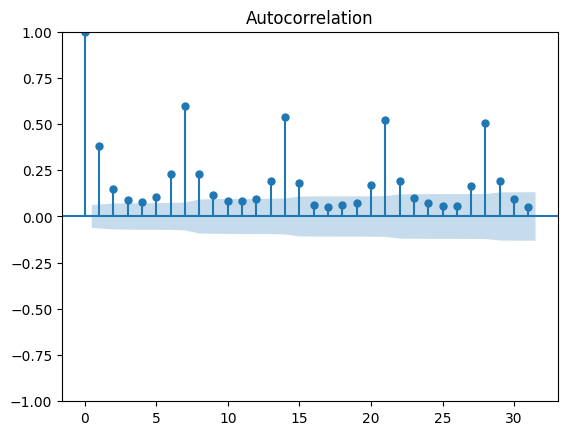

In [25]:
plot_acf(consumo_agua_ts)
plt.show()

Auto-Correlación  
`q=18`

#### Auto-correlación Parcial PACF

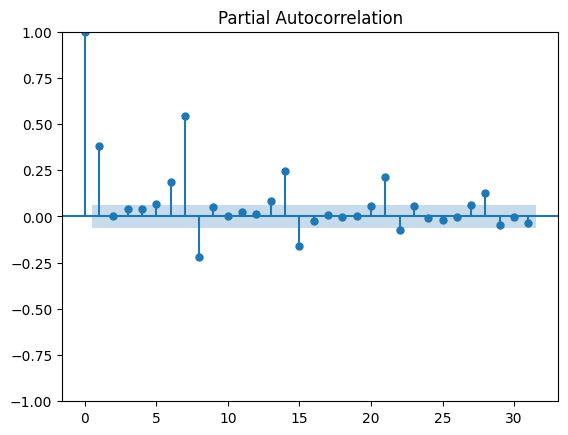

In [26]:
plot_pacf(consumo_agua_ts)
plt.show()

Coeficiente de Autocorrelacion Parcial (PACF)  
`p=11`

De forma manual los parámetros encontrados para ARIMA(p,d,q) son:
- p = 11
- d = 0 (No se toma en consideración)
- q = 18  

- Quedando: `ARIMA(11, 0, 18)`

### Parte 4

- d) Utilizando 15 días para pruebas y el resto de fechas para entrenamiento, genere el modelo usando los parámetros del item anterior.

In [27]:
days_test = 15 # días
train_test_ca = train_test(consumo_agua_ts, test_size=days_test)

Train: 990 
Test : 15


In [28]:
modelo_arima = SARIMAX(
    train_test_ca['train'],
    order=(11, 0, 18)
)
modelo_arima_fit = modelo_arima.fit(disp=False)
pred_arima = modelo_arima_fit.forecast(days_test)

In [29]:
pred_arima

2021-11-16    2579.572379
2021-11-17    4199.165685
2021-11-18    4483.715684
2021-11-19    4546.504304
2021-11-20    4628.213390
2021-11-21    4482.807230
2021-11-22    4137.579450
2021-11-23    2593.922815
2021-11-24    4185.164531
2021-11-25    4477.186306
2021-11-26    4544.828060
2021-11-27    4624.448248
2021-11-28    4465.206194
2021-11-29    4139.876297
2021-11-30    2622.038336
Freq: D, Name: predicted_mean, dtype: float64

### Parte 5
- e) Genere también los métodos `Holt-Winters`, `Holt-Winters Calibrado`, `Deep Learning`, `AUTO ARIMA` y `SARIMA Calibrado` y compare los resultados.

In [30]:
def modelos_ts(ts, test_size, forecast, periods=None, is_holt_winters = False, is_holt_winters_calibrado = False, is_lstm = False):
    train_test_division = train_test(ts, test_size)
    if is_holt_winters is True:
        holt_winters = ExponentialSmoothing(train_test_division['train'], trend = 'add', seasonal = 'add', seasonal_periods=periods)
        holt_winters_fit = holt_winters.fit()
        pred = holt_winters_fit.forecast(forecast)
    
    elif is_holt_winters_calibrado is True:
        hw_calibrado = HW_calibrado(train_test_division['train'], train_test_division['test'], seasonal_periods=periods)
        hw_calibrado_fit = hw_calibrado.fit(0.05)
        pred = hw_calibrado_fit.forecast(forecast)
        print(
            'alpha: ', hw_calibrado_fit.alpha,
            '\nbeta : ', hw_calibrado_fit.beta,
            '\ngamma: ', hw_calibrado_fit.gamma)
        
    elif is_lstm is True:
        lstm = LSTM_TS(train_test_division['train'])
        lstm_fit = lstm.fit()
        pred = lstm_fit.forecast(forecast)
    
    return pred

#### Holt-Winters

In [31]:
pred_hw = modelos_ts(consumo_agua_ts, test_size=days_test, periods=7, forecast=days_test, is_holt_winters=True)

Train: 990 
Test : 15


In [32]:
pred_hw

2021-11-16    2410.954395
2021-11-17    4334.734163
2021-11-18    4611.831801
2021-11-19    4574.903791
2021-11-20    4663.064086
2021-11-21    4584.561828
2021-11-22    4217.934883
2021-11-23    2420.032764
2021-11-24    4343.812533
2021-11-25    4620.910171
2021-11-26    4583.982161
2021-11-27    4672.142456
2021-11-28    4593.640198
2021-11-29    4227.013253
2021-11-30    2429.111134
Freq: D, dtype: float64

#### Holt-Winters Calibrado

In [33]:
pred_hw_calibrado = modelos_ts(consumo_agua_ts, test_size=days_test, periods=7, forecast=days_test, is_holt_winters_calibrado=True)

Train: 990 
Test : 15
alpha:  0.1 
beta :  0.8 
gamma:  0.0


In [34]:
pred_hw_calibrado

2021-11-16    3076.556359
2021-11-17    4013.511191
2021-11-18    4240.826014
2021-11-19    4335.425838
2021-11-20    4331.065647
2021-11-21    4266.617278
2021-11-22    3921.555373
2021-11-23    3404.186587
2021-11-24    4341.141419
2021-11-25    4568.456242
2021-11-26    4663.056067
2021-11-27    4658.695875
2021-11-28    4594.247506
2021-11-29    4249.185602
2021-11-30    3731.816815
Freq: D, dtype: float64

#### Deep Learning

In [35]:
pred_lstm = modelos_ts(consumo_agua_ts, test_size=days_test, forecast=days_test, is_lstm=True)

Train: 990 
Test : 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [36]:
pred_lstm

2021-11-16    3995.009521
2021-11-17    3672.568115
2021-11-18    3709.683838
2021-11-19    3670.934082
2021-11-20    3539.041016
2021-11-21    3577.952881
2021-11-22    3386.430420
2021-11-23    3448.261230
2021-11-24    3174.684326
2021-11-25    3088.663086
2021-11-26    3338.332031
2021-11-27    3318.826172
2021-11-28    3484.135010
2021-11-29    3571.513428
2021-11-30    3337.058350
Freq: D, dtype: float64

#### Auto ARIMA

In [37]:
mejor_periodo = int(round(periodograma_ca_ts.mejor_periodos(best=3)[0]))

In [38]:
auto_arima = AutoARIMA(season_length = mejor_periodo)
modelo_fit = auto_arima.fit(consumo_agua_ts)

In [39]:
arima_string(auto_arima.model_)

'ARIMA(1,0,0)(0,1,2)[7] with drift        '

In [40]:
modelo     = SARIMAX(train_test_ca['train'], order = [1, 0, 0], seasonal_order=[0, 1, 2, 7])
modelo_fit = modelo.fit(disp = False)
pred_auto_arima = modelo_fit.forecast(days_test)

In [41]:
pred_auto_arima

2021-11-16    2371.282407
2021-11-17    4305.623527
2021-11-18    4566.890482
2021-11-19    4522.832601
2021-11-20    4617.340917
2021-11-21    4550.719898
2021-11-22    4183.050213
2021-11-23    2389.148795
2021-11-24    4300.751259
2021-11-25    4568.470601
2021-11-26    4525.969785
2021-11-27    4615.193322
2021-11-28    4545.422147
2021-11-29    4182.261634
2021-11-30    2388.846757
Freq: D, Name: predicted_mean, dtype: float64

#### SARIMA Calibrado

In [42]:
sarima_calibrado     = SARIMA_calibrado(train_test_ca['train'], train_test_ca['test'])
sarima_calibrado_fit = sarima_calibrado.fit(S = mejor_periodo)

print("ARIMA (" + str(sarima_calibrado_fit.p) + ", " + str(sarima_calibrado_fit.d) +
      ", " + str(sarima_calibrado_fit.q) + ") (" + str(sarima_calibrado_fit.P) + 
      ", " + str(sarima_calibrado_fit.D) + ", " + str(sarima_calibrado_fit.Q) +
      ") [" + str(sarima_calibrado_fit.S) + "]")

ARIMA (0, 2, 1) (1, 0, 0) [7]


In [43]:
pred_sarima_calibrado = sarima_calibrado_fit.forecast(days_test)
pred_sarima_calibrado

2021-11-16    2948.522795
2021-11-17    4272.173704
2021-11-18    4378.929440
2021-11-19    4351.553130
2021-11-20    4444.366920
2021-11-21    4429.564667
2021-11-22    4183.089353
2021-11-23    3440.555039
2021-11-24    4234.174582
2021-11-25    4300.268940
2021-11-26    4286.171969
2021-11-27    4343.931084
2021-11-28    4337.351559
2021-11-29    4192.265455
2021-11-30    3750.608683
Freq: D, Name: predicted_mean, dtype: float64

#### Comparación de Resultados

In [44]:
errores_ca = ts_error(
    [pred_arima, pred_hw, pred_hw_calibrado, pred_lstm, pred_auto_arima, pred_sarima_calibrado],
    train_test_ca['test'],
    ["ARIMA", "Holt-Winters", "Holt-Winters Calibrado", "Redes Neuronales (LSTM)", "Auto ARIMA", "SARIMA Calibrado"],
)
errores_ca.df_errores().sort_values(by=['MSE', 'RMSE', 'RE', 'CORR'], ascending=[True, True, True, False])

,MSE,RMSE,RE,CORR
Holt-Winters Calibrado,2.643875e+05,514.186211,0.095719,0.823965
SARIMA Calibrado,2.804838e+05,529.607241,0.104420,0.823029
ARIMA,3.948394e+05,628.362514,0.096658,0.678263
Holt-Winters,4.485371e+05,669.729097,0.101241,0.674005
Auto ARIMA,4.518315e+05,672.184115,0.100254,0.672077
Redes Neuronales (LSTM),1.285961e+06,1134.002110,0.251566,-0.570635


In [45]:
fig = errores_ca.plotly_errores()
fig.show()

El Modelo que tiene mayor balance general seria el `Holt Winters Calibrado`, con:
- Menor `MSE`: 264387.5
- Menor `RMSE`: 514.18
- Menor `RE`: 0.095
- `CORR`: positiva, muy cercana a 1 siguiendo la tendencia (0.823965)

Se puede apreciar que `SARIMA Calibrado` se le acerca bastante, siento el 2do mejor modelo.
- `MSE`: 280483.8
- `RMSE`: 529.60
- `RE`: 0.104
- `CORR`: positiva, cercana a 1 (0.823029)

Se podría describir de esto que, el modelo HW Calibrado, en promedio se equivocaa 514.18 unidades de agua por día, que equivalente a un error aproximado del 9.5% respecto al consumo real y muestra una fuerte correlación lineal positiva (0.82) que valida que el modelo sigue de cerca la tendencia y fluctuaciones de la serie real.


In [46]:
def predictions_chart2(train, test, holt_winters, hw_calibrado, lstm, auto_arima, sarima_calibrado, arima=None, lines="lines+markers"):
    fig = go.Figure()

    models = [train, test, holt_winters, hw_calibrado, lstm, auto_arima, sarima_calibrado, arima]
    import inspect
    def obtener_nombre_variable(variable):
        locales = inspect.currentframe().f_back.f_locals.items()
        nombres = [nombre for nombre, valor in locales if valor is variable]
        return nombres
    for model in models:
        if model is not None:
            no_plot = fig.add_trace(
                go.Scatter(
                    x=model.index.tolist(),
                    y=model.values.tolist(),
                    mode=lines,  # lines+markers
                    name=str(obtener_nombre_variable(model)[0]),
                )
            )
        else:
            pass
    no_plot = fig.update_xaxes(rangeslider_visible=True)
    fig.show()
    
predictions_chart2(train_test_ca['train'],
                   train_test_ca['test'],
                #    pred_arima,
                   pred_hw,
                   pred_hw_calibrado,
                   pred_lstm,
                   pred_auto_arima,
                   pred_sarima_calibrado,
                   lines="lines"
                   )

<a id="ej2"></a>
# Ejercicio 2
[35 puntos] El archivo `homicidiosCR_v1.csv` contiene la cantidad de homicidios mensuales en Costa Rica desde *enero del 2020* hasta *agosto del 2024*. Con la tabla realice lo siguiente:
- a) Convierta a serie de tiempo.
- b) Gráfique la autocorrelación Simple y la Parcial.
- c) Determine y grafique los 6 periodos más importantes.
- d) Usando 3 meses para pruebas y el resto de fechas para entrenamiento genere modelos utilizando `Holt-Winters`, `Holt-Winters Calibrado`, `Deep Learning`, `AUTO ARIMA` y `SARIMA
Calibrado`, para este último utilice el sexto periodo más importante encontrado en el punto anterior.
- e) Con un gráfico mida el error de cada uno de los modelos anteriores y determine cual de ellos es el mejor.
- f) Con el mejor modelo encontrado en el punto anterior genere la predicción de 3 meses, pero esta vez utilizando toda la serie de tiempo. Grafique la serie original y la predicción.


[↑ Volver al Menú](#menu)


### Preparación de los datos

In [47]:
homicidios = pd.read_csv("../../w1/h1/hocimidiosCR_v1.csv", delimiter=";")
homicidios.head(10)

,Fecha,Homicidios
0,2020-01-01,49
1,2020-02-01,46
2,2020-03-01,48
3,2020-04-01,36
4,2020-05-01,48
5,2020-06-01,43
6,2020-07-01,49
7,2020-08-01,41
8,2020-09-01,50
9,2020-10-01,58


In [48]:
homicidios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Fecha       56 non-null     object
 1   Homicidios  56 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.0+ KB


In [49]:
homicidios["Homicidios"] = homicidios["Homicidios"].astype("int64")
homicidios["Fecha"] = homicidios["Fecha"].astype("datetime64[ns]")

In [50]:
homicidios.isnull().sum()

Fecha         0
Homicidios    0
dtype: int64

In [51]:
faltan_fechas = hay_fechas_faltantes(homicidios, col_name_date="Fecha", frequency="MS")

Fechas faltantes: 0


### Parte 1
- a) Convierta a serie de tiempo.

In [52]:
homicidios_ts = to_serie_tiempo(homicidios, col_name_date="Fecha", col_name_values="Homicidios", frequency="MS")
homicidios_ts[:5]

Fecha
2020-01-01    49
2020-02-01    46
2020-03-01    48
2020-04-01    36
2020-05-01    48
Freq: MS, Name: Homicidios, dtype: int64

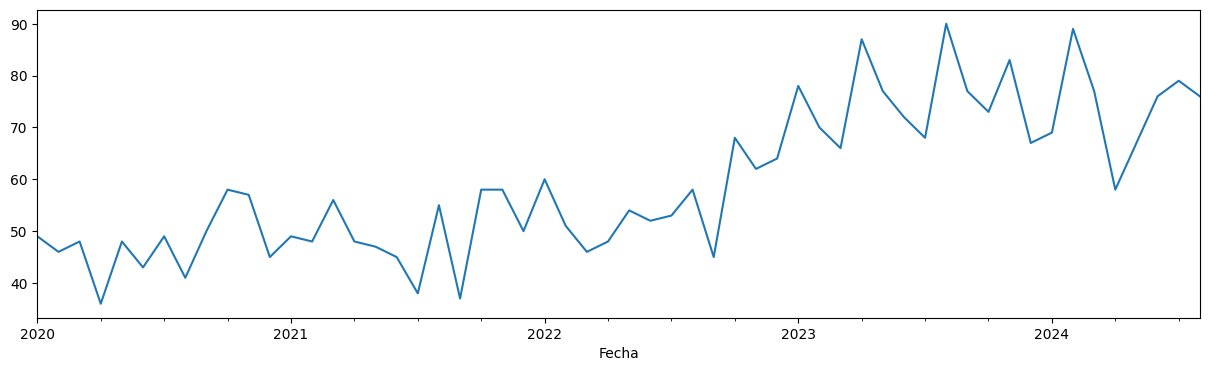

In [53]:
homicidios_ts.plot(figsize=(15, 4))
plt.show()

### Parte 2
- b) Gráfique la autocorrelación Simple y la Parcial.

#### Auto-correlación Simple ACF

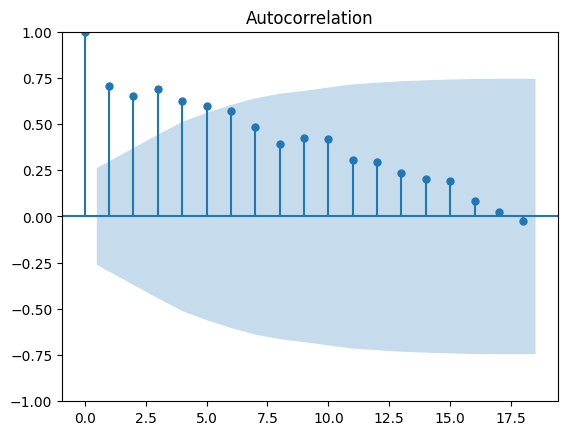

In [54]:
plot_acf(homicidios_ts)
plt.show()

Autocorrelación ACF  
`q=5`

#### Auto-correlación Parcial PACF

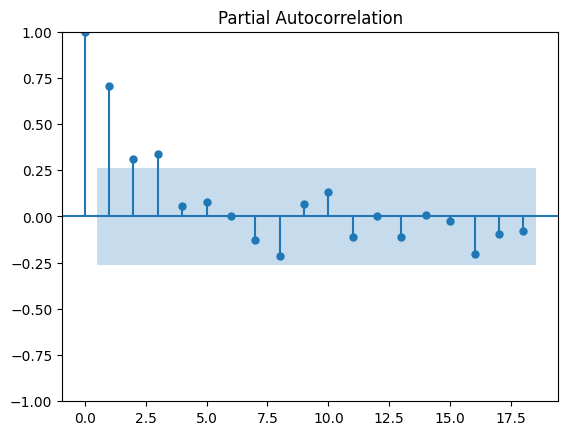

In [55]:
plot_pacf(homicidios_ts)
plt.show()

Coeficiente de Autocorrelacion Parcial (PACF)  
`p=3`

De forma manual los parámetros encontrados para ARIMA(p,d,q) son:
- p = 3
- d = 0 (No se toma en consideración)
- q = 5  

- Quedando: `ARIMA(3, 0, 5)`

### Parte 3

- c) Determine y grafique los 6 periodos más importantes.

In [56]:
periodograma_homicidios_ts = Periodograma(homicidios_ts)
print('mejor_freq\n', periodograma_homicidios_ts.mejor_freq(best=6))
print('\nmejor_periodos\n', periodograma_homicidios_ts.mejor_periodos(best=6))


mejor_freq
 [0.03571429 0.07142857 0.19642857 0.32142857 0.41071429 0.33928571]

mejor_periodos
 [28.         14.          5.09090909  3.11111111  2.43478261  2.94736842]


In [57]:
fig = periodograma_homicidios_ts.plotly_periodograma(best=6)
fig.show()

### Parte 4

- d) Usando 3 meses para pruebas y el resto de fechas para entrenamiento genere modelos utilizando `Holt-Winters`, `Holt-Winters Calibrado`, `Deep Learning`, `AUTO ARIMA` y `SARIMA Calibrado`, para este último utilice el sexto periodo más importante encontrado en el punto anterior.

In [58]:
days_test = 3 # meses
train_test_homicidios = train_test(homicidios_ts, test_size=days_test)

Train: 53 
Test : 3


#### Holt-Winters

In [59]:
pred_hw_h = modelos_ts(homicidios_ts, test_size=days_test, periods=12, forecast=days_test, is_holt_winters=True)
pred_hw_h

Train: 53 
Test : 3


2024-06-01    68.122993
2024-07-01    67.121578
2024-08-01    76.121514
Freq: MS, dtype: float64

#### Holt-Winters Calibrado

In [60]:
pred_hw_calibrado_h = modelos_ts(homicidios_ts, test_size=days_test, periods=12, forecast=days_test, is_holt_winters_calibrado=True)
pred_hw_calibrado_h

Train: 53 
Test : 3
alpha:  0.05 
beta :  0.8500000000000001 
gamma:  0.0


2024-06-01    78.440297
2024-07-01    73.942631
2024-08-01    79.529540
Freq: MS, dtype: float64

#### Deep Learning

In [61]:
pred_lstm_h = modelos_ts(homicidios_ts, test_size=days_test, forecast=days_test, is_lstm=True)
pred_lstm_h

Train: 53 
Test : 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


2024-06-01    63.393669
2024-07-01    60.993542
2024-08-01    59.799431
Freq: MS, dtype: float64

#### Auto ARIMA

In [62]:
mejor_periodo_6 = int(round(periodograma_homicidios_ts.mejor_periodos(best=6)[-1]))

auto_arima_h = AutoARIMA(season_length = mejor_periodo_6)
modelo_fit = auto_arima_h.fit(homicidios_ts)
arima_string(auto_arima_h.model_)

'ARIMA(0,1,1) with drift        '

In [63]:
modelo     = SARIMAX(train_test_homicidios['train'], order = [1, 0, 0], seasonal_order=[0, 1, 2, 7])
modelo_fit = modelo.fit(disp = False)
pred_auto_arima_h = modelo_fit.forecast(days_test)
pred_auto_arima_h

2024-06-01    75.710780
2024-07-01    67.079471
2024-08-01    66.425152
Freq: MS, Name: predicted_mean, dtype: float64

#### SARIMA Calibrado
Para este último utilice el sexto periodo más importante encontrado en el punto anterior.

In [64]:
mejor_periodo_6 = int(round(periodograma_homicidios_ts.mejor_periodos(best=6)[-1]))

sarima_calibrado_h = SARIMA_calibrado(train_test_homicidios['train'], train_test_homicidios['test'])
sarima_calibrado_h_fit = sarima_calibrado_h.fit(S=mejor_periodo_6)
print("ARIMA (" + str(sarima_calibrado_h_fit.p) + ", " + str(sarima_calibrado_h_fit.d) +
      ", " + str(sarima_calibrado_h_fit.q) + ") (" + str(sarima_calibrado_h_fit.P) + 
      ", " + str(sarima_calibrado_h_fit.D) + ", " + str(sarima_calibrado_h_fit.Q) +
      ") [" + str(sarima_calibrado_h_fit.S) + "]")

ARIMA (0, 2, 0) (0, 0, 1) [3]


In [65]:
pred_sarima_calibrado_h = sarima_calibrado_h_fit.forecast(days_test)
pred_sarima_calibrado_h

2024-06-01    70.069130
2024-07-01    70.953329
2024-08-01    77.011243
Freq: MS, Name: predicted_mean, dtype: float64

### Parte 5
- e) Con un gráfico mida el error de cada uno de los modelos anteriores y determine cual de ellos es el mejor.

In [66]:
errores_homicidios = ts_error([
    pred_hw_h,
    pred_hw_calibrado_h,
    pred_lstm_h, 
    pred_auto_arima_h, 
    pred_sarima_calibrado_h],
    train_test_homicidios['test'],
    ["Holt-Winters", "Holt-Winters Calibrado", "Redes Neuronales (LSTM)", "Auto ARIMA", "SARIMA Calibrado"],
)
errores_homicidios.df_errores().sort_values(by=['MSE', 'RMSE', 'RE', 'CORR'], ascending=[True, True, True, False])

,MSE,RMSE,RE,CORR
Holt-Winters Calibrado,14.663227,3.829259,0.047737,-0.982947
SARIMA Calibrado,33.648914,5.800768,0.064887,-0.395244
Holt-Winters,67.719634,8.229194,0.086047,-0.585329
Auto ARIMA,77.953456,8.829125,0.094306,-0.444333
Redes Neuronales (LSTM),248.536853,15.765052,0.202655,-0.190189


In [67]:
fig = errores_homicidios.plotly_errores()
fig.show()

El Modelo que tiene mayor balance general seria el `Holt Winters Calibrado`, con:
- Menor `MSE`: 14.663227
- Menor `RMSE`: 3.829259
- Menor `RE`: 0.047737
- `CORR`: fuerta correlación negativa (-0.982947)  

Entonces el modelo HW Calibrado, en promedio se equivocaa 3.82 homicidios mensuales, que equivalente a un error aproximado del 4.8% respecto la cantidad real. Se destaca la fuerte correlación negativa (-98.3%) dada por el tamaño reducido del conjunto de pruebas (3 meses de prueba), pero el modelo sigue siendo el mejor por RE, MSE y RMSE (que minimizan bien el error).

In [68]:
predictions_chart2(train_test_homicidios['train'],
                   train_test_homicidios['test'],
                   pred_hw_h,
                   pred_hw_calibrado_h,
                   pred_lstm_h, 
                   pred_auto_arima_h, 
                   pred_sarima_calibrado_h,
                #    lines="lines"
                    )

### Parte 6

- f) Con el mejor modelo encontrado en el punto anterior genere la predicción de 3 meses, pero esta vez utilizando toda la serie de tiempo. Grafique la serie original y la predicción.

In [69]:
hwc_final_h = ExponentialSmoothing(homicidios_ts, trend="add", seasonal="add")
hwc_final_h_fit = hwc_final_h.fit(smoothing_level=0.05, smoothing_slope=0.85, smoothing_seasonal=0.0)
pred_hwc_final_h = hwc_final_h_fit.forecast(3)
pred_hwc_final_h

2024-09-01    67.399384
2024-10-01    76.121837
2024-11-01    73.679443
Freq: MS, dtype: float64

In [70]:
fig = go.Figure()
no_plot = fig.add_trace(
    go.Scatter(
        x=homicidios_ts.index.tolist(),
        y=homicidios_ts.values.tolist(),
        mode="lines+markers",
        name="Original",
    )
)
no_plot = fig.add_trace(
    go.Scatter(
        x=pred_hwc_final_h.index.tolist(),
        y=pred_hwc_final_h.values.tolist(),
        mode="lines+markers",
        name="Predicción",
    )
)

no_plot = fig.update_xaxes(rangeslider_visible=True)
fig.show()

<a id="ej3"></a>
# Ejercicio 3 
[35 puntos] La tabla `traficoweb_v1.csv` contiene la cantidad de usuarios que ingresan a una determinada página web por día desde el 14 de setiembre del 2014 al 19 de agosto del 2020.
Con la tabla realice lo siguiente:
- a) Verifique si hay fechas faltantes y de ser así relice la corrección mediante un suavizado (Utilice el valor que usted considere).
- b) Convierta a serie de tiempo.
- c) Usando las últimas 2 semanas para pruebas y el resto de fechas para entrenamiento genere un modelo con `Holt-Winters`, `Holt-Winters Calibrado`, `Deep Learning`, `AUTO ARIMA`
y `SARIMA Calibrado`, para este último utilice un periodo de 7.
- d) Con un gráfico mida el error de cada uno de los modelos anteriores y determine cuál de ellos es el mejor.
- e) Con el mejor modelo encontrado en el punto anterior genere la predicción de una semana, pero esta vez utilizando toda la serie de tiempo. Grafique la serie original y la predicción.

**NOTA: Toda conversión a serie de tiempo debe incluir la frecuencia correspondiente.**

[↑ Volver al Menú](#menu)

### Preparación de los datos

In [71]:
traficoWeb = pd.read_csv("../../w1/h1/traficoweb_v1.csv", delimiter=";")
traficoWeb

,Fecha,Visitas
0,9/14/2014,1582
1,9/15/2014,2528
2,9/16/2014,2630
3,9/17/2014,2614
4,9/18/2014,2366
...,...,...
2155,8/15/2020,1696
2156,8/16/2020,2037
2157,8/17/2020,2638
2158,8/18/2020,2683


In [72]:
traficoWeb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Fecha    2160 non-null   object
 1   Visitas  2160 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 33.9+ KB


In [73]:
traficoWeb['Fecha'] = traficoWeb['Fecha'].astype('datetime64[ns]') 

In [74]:
traficoWeb.isnull().sum()

Fecha      0
Visitas    0
dtype: int64

### Parte 1
- a) Verifique si hay fechas faltantes y de ser así relice la corrección mediante un suavizado (Utilice el valor que usted considere).
- b) Convierta a serie de tiempo.

In [75]:
faltan_fechas = hay_fechas_faltantes(traficoWeb, 'Fecha', 'D')

Fechas faltantes: -7


In [76]:
traficoWeb_f = rellenar_fechas(
    traficoWeb,
    col_name_date="Fecha",
    serie_fechas_completas=faltan_fechas["date_range"],
)
print("len: ", len(traficoWeb_f))

Primeras 5 filas:
 [Timestamp('2014-10-01 00:00:00'), Timestamp('2015-04-28 00:00:00'), Timestamp('2018-07-09 00:00:00'), Timestamp('2019-09-21 00:00:00'), Timestamp('2019-12-22 00:00:00')]

Valores faltantes:  0
len:  2167


In [77]:
traficoWeb_ts = to_serie_tiempo(traficoWeb_f, "Fecha", "Visitas", frequency="D")

In [78]:
traficoWeb_ts_3 = imputar_valores_faltantes_suavizados(
    traficoWeb_f,
    col_name_values="Visitas",
    size=3,
    to_serie=True,
    frequency="D",
    col_name_date="Fecha",
)

Todos los valores faltantes fueron imputados con suavizado de 3 datos.


In [79]:
traficoWeb_ts_3.isnull().sum()

0

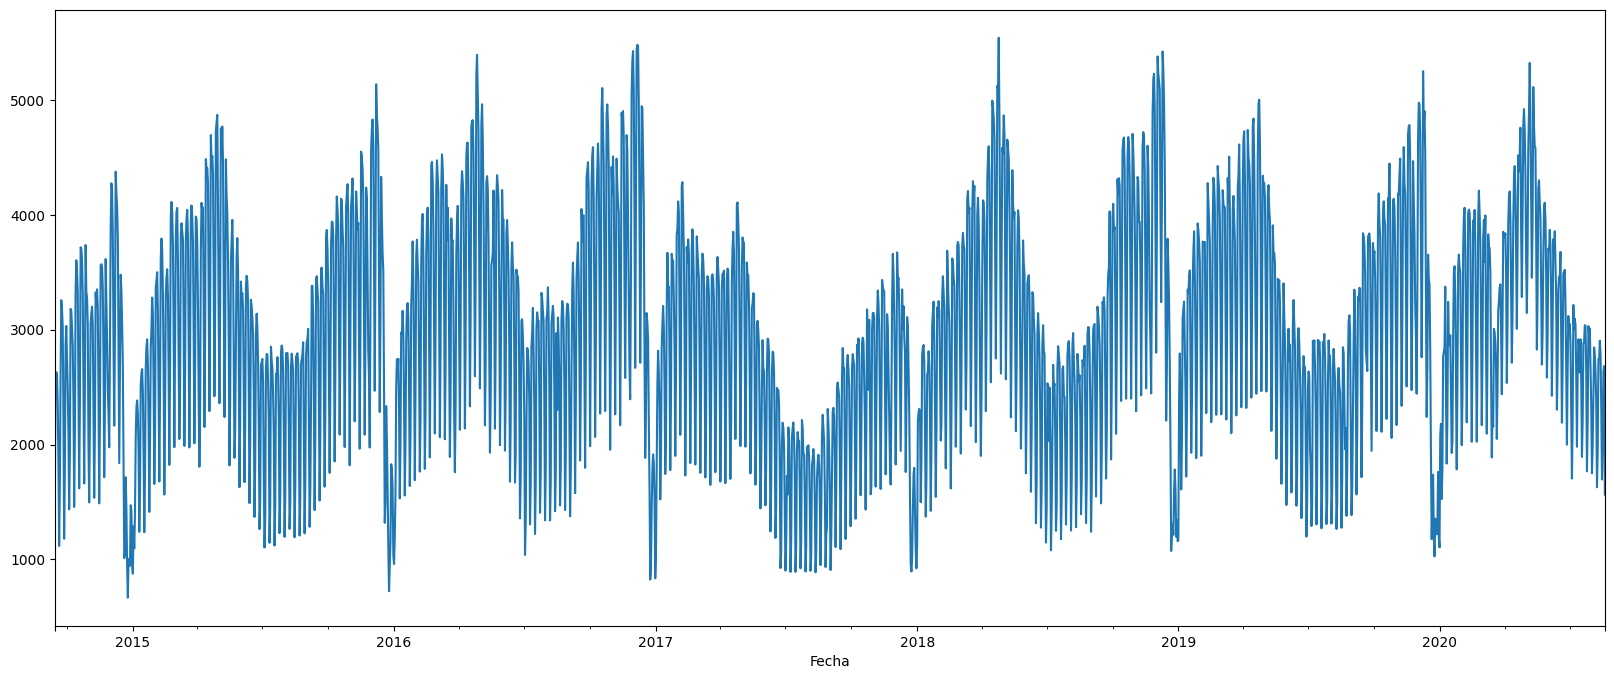

In [80]:
traficoWeb_ts_3.plot(figsize=(20, 8))
plt.show()

### Parte 2
- c) Usando las últimas 2 semanas para pruebas y el resto de fechas para entrenamiento genere un modelo con `Holt-Winters`, `Holt-Winters Calibrado`, `Deep Learning`, `AUTO ARIMA` y `SARIMA Calibrado`, para este último utilice un periodo de 7.

In [81]:
days_test = 14 # días => 2 semanas
train_test_tw = train_test(traficoWeb_ts_3, test_size=days_test)

Train: 2153 
Test : 14


#### Holt-Winters

In [82]:
pred_holt_winters_t = modelos_ts(traficoWeb_ts_3, test_size=days_test, periods=7, forecast=days_test, is_holt_winters=True)
pred_holt_winters_t

Train: 2153 
Test : 14


2020-08-06    2591.443837
2020-08-07    1898.812124
2020-08-08    1021.367966
2020-08-09    1544.124393
2020-08-10    2663.600569
2020-08-11    2778.283591
2020-08-12    2754.345296
2020-08-13    2571.674894
2020-08-14    1879.043181
2020-08-15    1001.599022
2020-08-16    1524.355450
2020-08-17    2643.831626
2020-08-18    2758.514647
2020-08-19    2734.576353
Freq: D, dtype: float64

#### Holt-Winters Calibrado

In [83]:
pred_hw_calibrado_t = modelos_ts(traficoWeb_ts_3, test_size=days_test, periods=7, forecast=days_test, is_holt_winters_calibrado=True)

Train: 2153 
Test : 14
alpha:  0.6000000000000001 
beta :  0.05 
gamma:  0.35000000000000003


In [84]:
pred_hw_calibrado_t

2020-08-06    2672.401910
2020-08-07    2345.834236
2020-08-08    1664.414443
2020-08-09    1998.255634
2020-08-10    2623.374666
2020-08-11    2778.708521
2020-08-12    2665.216707
2020-08-13    2589.695274
2020-08-14    2263.127600
2020-08-15    1581.707806
2020-08-16    1915.548997
2020-08-17    2540.668029
2020-08-18    2696.001884
2020-08-19    2582.510070
Freq: D, dtype: float64

#### Deep Learning

In [85]:
pred_lstm_t = modelos_ts(traficoWeb_ts_3, test_size=days_test, forecast=days_test, is_lstm=True)
pred_lstm_t

Train: 2153 
Test : 14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


2020-08-06    2942.255859
2020-08-07    2842.321777
2020-08-08    2783.398926
2020-08-09    2737.176025
2020-08-10    2667.030273
2020-08-11    2769.248047
2020-08-12    2842.102783
2020-08-13    2783.958252
2020-08-14    2858.610840
2020-08-15    2723.827637
2020-08-16    2724.576904
2020-08-17    2798.269531
2020-08-18    2837.984375
2020-08-19    2838.390625
Freq: D, dtype: float64

#### Auto ARIMA

In [86]:
periodograma_tw = Periodograma(traficoWeb_ts_3)
print('mejor_freq\n', periodograma_tw.mejor_freq(best=3))
print('\nmejor_periodos\n', periodograma_tw.mejor_periodos(best=3))

mejor_freq
 [0.14305491 0.00553761 0.14259345]

mejor_periodos
 [  6.99032258 180.58333333   7.01294498]


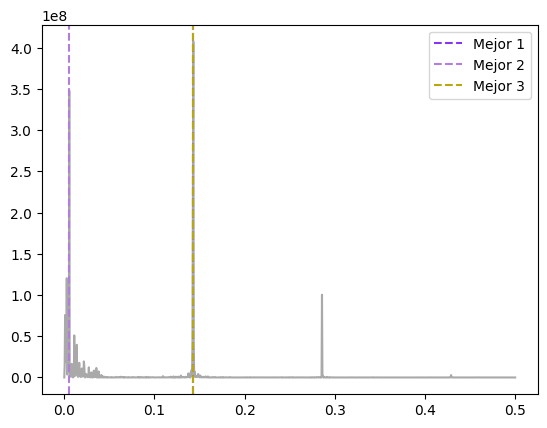

In [87]:
periodograma_tw.plot_periodograma(best=3)

In [88]:
mejor_periodo= int(round(periodograma_tw.mejor_periodos(best=3)[0]))

auto_arima_t = AutoARIMA(season_length = mejor_periodo)
modelo_fit_t = auto_arima_t.fit(traficoWeb_ts_3)
arima_string(auto_arima_t.model_)

'ARIMA(2,0,3)(2,1,1)[7]                   '

In [89]:
modelo_f = SARIMAX(train_test_tw['train'], order = [2, 0, 3], seasonal_order=[2, 1, 1, 7])
modelo_fit_t = modelo_f.fit(disp = False)
pred_auto_arima_t = modelo_fit_t.forecast(days_test)
pred_auto_arima_t

2020-08-06    2570.828576
2020-08-07    2099.629565
2020-08-08    1486.785779
2020-08-09    1885.694423
2020-08-10    2668.396150
2020-08-11    2855.999395
2020-08-12    2880.325612
2020-08-13    2723.373195
2020-08-14    2213.961566
2020-08-15    1523.767158
2020-08-16    2016.103426
2020-08-17    2859.229339
2020-08-18    3009.107154
2020-08-19    3020.214061
Freq: D, Name: predicted_mean, dtype: float64

#### SARIMA Calibrado

para este último utilice un periodo de 7

In [90]:
sarima_calibrado_t     = SARIMA_calibrado(train_test_tw['train'], train_test_tw['test'])

# periodo_7= int(round(periodograma_tw.mejor_periodos(best=7)[-1]))


sarima_calibrado_t_fit = sarima_calibrado_t.fit(S = 7)
print(f"ARIMA ({str(sarima_calibrado_t_fit.p)}, {str(sarima_calibrado_t_fit.d)}, {str(sarima_calibrado_t_fit.q)}) "
      f"({str(sarima_calibrado_t_fit.P)}, {str(sarima_calibrado_t_fit.D)}, {str(sarima_calibrado_t_fit.Q)}) "
      f"[{str(sarima_calibrado_t_fit.S)}]")

ARIMA (0, 1, 0) (1, 0, 1) [7]


In [91]:
pred_sarima_calibrado_t = sarima_calibrado_t_fit.forecast(days_test)
pred_sarima_calibrado_t

2020-08-06    2682.485209
2020-08-07    2250.973297
2020-08-08    1574.909978
2020-08-09    1973.093970
2020-08-10    2593.788349
2020-08-11    2672.048357
2020-08-12    2676.554755
2020-08-13    2585.534108
2020-08-14    2156.352192
2020-08-15    1483.939352
2020-08-16    1879.973305
2020-08-17    2497.316177
2020-08-18    2575.153611
2020-08-19    2579.635677
Freq: D, Name: predicted_mean, dtype: float64

### Parte 3
- d) Con un gráfico mida el error de cada uno de los modelos anteriores y determine cuál de ellos es el mejor.

In [92]:
errores_traficoWeb = ts_error([
    pred_holt_winters_t,
    pred_hw_calibrado_t,
    pred_lstm_t, 
    pred_auto_arima_t, 
    pred_sarima_calibrado_t],
    train_test_tw['test'],
    ["Holt-Winters", "Holt-Winters Calibrado", "Redes Neuronales (LSTM)", "Auto ARIMA", "SARIMA Calibrado"],
)
errores_traficoWeb.df_errores().sort_values(by=['MSE', 'RMSE', 'RE', 'CORR'], ascending=[True, True, True, False])

,MSE,RMSE,RE,CORR
Holt-Winters Calibrado,85241.903653,291.962161,0.066027,0.772487
SARIMA Calibrado,92342.674619,303.879375,0.082183,0.759159
Auto ARIMA,173803.517882,416.897491,0.094218,0.653658
Holt-Winters,222983.090528,472.210854,0.149007,0.727784
Redes Neuronales (LSTM),415364.035923,644.487421,0.207438,0.187838


In [93]:
fig = errores_traficoWeb.plotly_errores()
fig.show()

El Modelo que tiene mayor balance general seria el `Holt Winters Calibrado`, con:
- Menor `MSE`: 85241.903653
- Menor `RMSE`: 291.962161
- Menor `RE`: 0.066027
- `CORR`: medianamente cercana a 1, pero positiva, siguiendo la tendencia (0.772487)
			
Entonces el modelo HW Calibrado, en promedio se equivocaa 291.96 en visitas diarias, que equivalente a un error aproximado del 6.6% respecto a la cantidad real de visitas, con una correlación positiva moderada (0.77), replicando efectivamente la tendencia diaria.

El 2do mejor metodo es el de `SARIMA Calibrado` resumido así: El modelo SARIMA Calibrado, en promedio se equivocaa 303.88 en visitas diarias, que equivalente a un error aproximado del 8.2% respecto a la cantidad real de visitas, con una correlación positiva moderada (0.75), replicando la dentencia diaria.

En contraste tenemos el modelo con menor rendimiento `Redes Neuronales (LSTM)`, este en promedio se equivoca en 563.19 visitas diarias, equivalentes a un error aproximado del 18.79% y presenta una correlación prácticamente nula (-0.05), lo que demuestra su incapacidad para capturar las fluctuaciones diarias de la serie.

In [94]:
predictions_chart2(train_test_tw['train'],
                   train_test_tw['test'],
                   pred_holt_winters_t,
                   pred_hw_calibrado_t,
                   pred_lstm_t, 
                   pred_auto_arima_t, 
                   pred_sarima_calibrado_t,
                #    lines="lines"
                    )

### Parte 4

- e) Con el mejor modelo encontrado en el punto anterior genere la predicción de una semana, pero esta vez utilizando toda la serie de tiempo. Grafique la serie original y la predicción.

In [95]:
hwc_final_t = ExponentialSmoothing(traficoWeb_ts_3, trend="add", seasonal="add")
hwc_final_t_fit = hwc_final_t.fit(smoothing_level=0.60, smoothing_slope=0.05, smoothing_seasonal=0.35)
pred_hwc_final_t = hwc_final_t_fit.forecast(7)
pred_hwc_final_t

2020-08-20    1828.619399
2020-08-21    1420.907327
2020-08-22     742.760523
2020-08-23    1037.086623
2020-08-24    1660.583134
2020-08-25    1702.525398
2020-08-26    1706.487079
Freq: D, dtype: float64

In [96]:
fig = go.Figure()
no_plot = fig.add_trace(
    go.Scatter(
        x=traficoWeb_ts_3.index.tolist(),
        y=traficoWeb_ts_3.values.tolist(),
        mode="lines+markers",
        name="Original",
    )
)
no_plot = fig.add_trace(
    go.Scatter(
        x=pred_hwc_final_t.index.tolist(),
        y=pred_hwc_final_t.values.tolist(),
        mode="lines+markers",
        name="Predicción",
    )
)

no_plot = fig.update_xaxes(rangeslider_visible=True)
fig.show()